# retrofitting pre-built network
This is a general idea without validation!  

**pre-built network** means that we use a network that was created with the standard pypsa-eur workflow. In this case standard workflow refers to creating a network with the rule *solve_elec_network* with whatever configuration (config.yaml) you choose.  
(e.g.: snakemake -call solve_elec_networks --configfile ../config/FR_2020-08_6_clusters_2030.yaml --latency-wait 300 --cores all)  
The resulting .nc-file is then used in this retrofitting approach.

### loading network

In [67]:
import pypsa 
import pandas as pd
import numpy as np
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

INFO:pypsa.network.io:New version 1.1.2 available! (Current: 1.0.7)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks


{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x22c077f9e50>},
 'branches': {'Link': <matplotlib.collections.LineCollection at 0x22c077f9f90>,
  'Line': <matplotlib.collections.LineCollection at 0x22c077fa0d0>},
 'flows': {}}

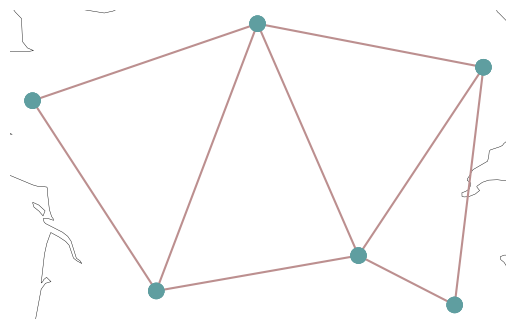

In [68]:
n = pypsa.Network("../results/FR_2020-08_6_clusters_2030/networks/base_s_6_elec_.nc")
n.plot()

### hydro and PHS static data

In [69]:
print(n.storage_units.keys())
print(n.storage_units_t.keys())

Index(['bus', 'control', 'type', 'p_nom', 'p_nom_mod', 'p_nom_extendable',
       'p_nom_min', 'p_nom_max', 'p_nom_set', 'p_min_pu', 'p_max_pu', 'p_set',
       'q_set', 'p_dispatch_set', 'p_store_set', 'sign', 'carrier',
       'spill_cost', 'marginal_cost', 'marginal_cost_quadratic',
       'marginal_cost_storage', 'capital_cost', 'active', 'build_year',
       'lifetime', 'state_of_charge_initial',
       'state_of_charge_initial_per_period', 'state_of_charge_set',
       'cyclic_state_of_charge', 'cyclic_state_of_charge_per_period',
       'max_hours', 'efficiency_store', 'efficiency_dispatch', 'standing_loss',
       'inflow', 'p_nom_opt'],
      dtype='object')
dict_keys(['p_min_pu', 'p_max_pu', 'p_set', 'q_set', 'p_dispatch_set', 'p_store_set', 'spill_cost', 'marginal_cost', 'marginal_cost_quadratic', 'marginal_cost_storage', 'state_of_charge_set', 'efficiency_store', 'efficiency_dispatch', 'standing_loss', 'inflow', 'p', 'p_dispatch', 'p_store', 'q', 'state_of_charge', 'spill',

In [70]:
n.storage_units.T

name,FR0 0 PHS,FR0 3 PHS,FR0 4 PHS,FR0 5 PHS,FR0 0 hydro,FR0 2 hydro,FR0 4 hydro,FR0 5 hydro
bus,FR0 0,FR0 3,FR0 4,FR0 5,FR0 0,FR0 2,FR0 4,FR0 5
control,PQ,PQ,PQ,PQ,PQ,PQ,PQ,PQ
type,,,,,,,,
p_nom,3660.0,240.0,1368.0,808.0,4629.101911,1866.196178,1694.152866,424.0
p_nom_mod,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
p_nom_extendable,False,False,False,False,False,False,False,False
p_nom_min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
p_nom_max,inf,inf,inf,inf,inf,inf,inf,inf
p_nom_set,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
p_min_pu,-1.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,0.0


In [71]:
# installed hydro capacities
hydro_capacities = n.storage_units[n.storage_units.carrier == "hydro"].copy()
hydro_capacities["storage_capacity"] = hydro_capacities.p_nom * hydro_capacities.max_hours
# list of relevant information
hydro_capacities[["bus", "carrier", "p_nom", "p_nom_extendable", "p_nom_opt", "p_min_pu", "p_max_pu",
                   "storage_capacity", "max_hours", "efficiency_store", "efficiency_dispatch"]].T

name,FR0 0 hydro,FR0 2 hydro,FR0 4 hydro,FR0 5 hydro
bus,FR0 0,FR0 2,FR0 4,FR0 5
carrier,hydro,hydro,hydro,hydro
p_nom,4629.101911,1866.196178,1694.152866,424.0
p_nom_extendable,False,False,False,False
p_nom_opt,4629.101911,1866.196178,1694.152866,424.0
p_min_pu,0.0,0.0,0.0,0.0
p_max_pu,1.0,1.0,1.0,1.0
storage_capacity,4079158.299381,1644489.530757,1492885.198441,373628.222548
max_hours,881.198638,881.198638,881.198638,881.198638
efficiency_store,0.0,0.0,0.0,0.0


Analysis of static hydro-data
- p_nom is different for each bus  
- max_hours is the same for each bus and probably way to high. For PHS 6 hours is right most of the time

In [72]:
# installed PHS capacities
PHS_capacities = n.storage_units[n.storage_units.carrier == "PHS"].copy()
PHS_capacities["storage_capacity"] = PHS_capacities.p_nom * PHS_capacities.max_hours
# list of relevant information
PHS_capacities[["bus", "carrier", "p_nom", "p_nom_extendable", "p_nom_opt", "p_min_pu", "p_max_pu",
                   "storage_capacity", "max_hours","efficiency_store", "efficiency_dispatch"]].T

name,FR0 0 PHS,FR0 3 PHS,FR0 4 PHS,FR0 5 PHS
bus,FR0 0,FR0 3,FR0 4,FR0 5
carrier,PHS,PHS,PHS,PHS
p_nom,3660.0,240.0,1368.0,808.0
p_nom_extendable,False,False,False,False
p_nom_opt,3660.0,240.0,1368.0,808.0
p_min_pu,-1.0,-1.0,-1.0,-1.0
p_max_pu,1.0,1.0,1.0,1.0
storage_capacity,42325.882195,1440.0,37103.146067,4503.0
max_hours,11.564449,6.0,27.122183,5.57302
efficiency_store,0.866025,0.866025,0.866025,0.866025


### hydro and PHS dynamic data

In [73]:
# dynamic data
for key in n.storage_units_t.keys():
    print(key)

p_min_pu
p_max_pu
p_set
q_set
p_dispatch_set
p_store_set
spill_cost
marginal_cost
marginal_cost_quadratic
marginal_cost_storage
state_of_charge_set
efficiency_store
efficiency_dispatch
standing_loss
inflow
p
p_dispatch
p_store
q
state_of_charge
spill
mu_upper
mu_lower
mu_state_of_charge_set
mu_energy_balance


In [74]:
# storage_units_t is a dictionary with the time series data for every bus and storage_unit-carrier. 
# not every key is actually time series data. The difference in is visible in the following:

for key, df in n.storage_units_t.items():
    # Test if DataFrame is not empty and contains at least some non-null values
    if not df.empty and not df.isnull().all().all():
        print(f"\n--- Time-Series for: {key} ---")
        display(df.head().T)
    else:
        print(f"Time-Series for: {key} is empty or contains no data.")

Time-Series for: p_min_pu is empty or contains no data.
Time-Series for: p_max_pu is empty or contains no data.
Time-Series for: p_set is empty or contains no data.
Time-Series for: q_set is empty or contains no data.
Time-Series for: p_dispatch_set is empty or contains no data.
Time-Series for: p_store_set is empty or contains no data.
Time-Series for: spill_cost is empty or contains no data.
Time-Series for: marginal_cost is empty or contains no data.
Time-Series for: marginal_cost_quadratic is empty or contains no data.
Time-Series for: marginal_cost_storage is empty or contains no data.
Time-Series for: state_of_charge_set is empty or contains no data.
Time-Series for: efficiency_store is empty or contains no data.
Time-Series for: efficiency_dispatch is empty or contains no data.
Time-Series for: standing_loss is empty or contains no data.

--- Time-Series for: inflow ---


snapshot,2020-08-01,2020-08-02,2020-08-03,2020-08-04,2020-08-05
name,,,,,
FR0 0 hydro,810.358057,827.707261,902.021743,973.420704,925.766693
FR0 2 hydro,326.691254,333.685487,363.644949,392.429035,373.217591
FR0 4 hydro,296.573818,302.923257,330.120777,356.251279,338.810924
FR0 5 hydro,74.224293,75.813384,82.620177,89.159925,84.795082



--- Time-Series for: p ---


snapshot,2020-08-01,2020-08-02,2020-08-03,2020-08-04,2020-08-05
name,,,,,
FR0 0 PHS,-4.183473e-09,5.503766e-09,8.184028e-09,1.483414e-08,-1.156053e+03
FR0 3 PHS,1.317575e-08,3.326872e-08,3.327292e-08,2.034363e-03,-2.531494e-08
FR0 4 PHS,-4.330439e-10,1.464563e+02,2.610881e+02,1.825944e+02,-9.930670e+02
FR0 5 PHS,1.517065e-08,1.328560e-08,1.328816e-08,7.378885e-05,-1.157378e-09
FR0 0 hydro,1.734226e-09,1.891621e+03,3.931318e+03,5.046313e-08,4.709736e-10
FR0 2 hydro,3.519051e+02,5.162778e+01,3.728547e+02,2.019189e+02,8.315209e-10
FR0 4 hydro,1.896706e-09,3.338415e+02,9.923498e+02,1.219218e+02,7.091059e-10
FR0 5 hydro,1.630898e-08,1.442367e-08,1.442133e-08,3.252876e+02,1.647217e-09



--- Time-Series for: p_dispatch ---


...

Time-Series for: q is empty or contains no data.

--- Time-Series for: state_of_charge ---


snapshot,2020-08-01,2020-08-02,2020-08-03,2020-08-04,2020-08-05
name,,,,,
FR0 0 PHS,8.324778e-07,6.711081e-07,4.357970e-07,1.647463e-08,2.402811e+04
FR0 3 PHS,5.638020e-02,5.637927e-02,5.637834e-02,4.138973e-07,9.323636e-07
FR0 4 PHS,1.635441e+04,1.229569e+04,5.060204e+03,4.580134e-08,2.064051e+04
FR0 5 PHS,2.049816e-03,2.049440e-03,2.049064e-03,4.159725e-06,4.172242e-06
FR0 0 hydro,2.017294e+06,1.986715e+06,1.903529e+06,1.926891e+06,1.949109e+06
FR0 2 hydro,8.253092e+05,8.319410e+05,8.307256e+05,8.347594e+05,8.437167e+05
FR0 4 hydro,7.456692e+05,7.440369e+05,7.254972e+05,7.307960e+05,7.389274e+05
FR0 5 hydro,1.857966e+05,1.876161e+05,1.895990e+05,1.830645e+05,1.850995e+05



--- Time-Series for: spill ---


snapshot,2020-08-01,2020-08-02,2020-08-03,2020-08-04,2020-08-05
name,,,,,
FR0 0 PHS,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
FR0 3 PHS,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
FR0 4 PHS,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
FR0 5 PHS,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
FR0 0 hydro,3.112163e-10,3.112163e-10,3.112163e-10,3.112163e-10,3.112163e-10
FR0 2 hydro,2.908379e-10,2.908379e-10,2.908379e-10,2.908379e-10,2.908379e-10
FR0 4 hydro,2.908343e-10,2.908343e-10,2.908343e-10,2.908343e-10,2.908343e-10
FR0 5 hydro,2.908553e-10,2.908552e-10,2.908551e-10,2.908550e-10,2.908550e-10


Time-Series for: mu_upper is empty or contains no data.
Time-Series for: mu_lower is empty or contains no data.
Time-Series for: mu_state_of_charge_set is empty or contains no data.
Time-Series for: mu_energy_balance is empty or contains no data.


Time-Series for: p_min_pu is empty or contains no data.
Time-Series for: p_max_pu is empty or contains no data.
Time-Series for: p_set is empty or contains no data.
Time-Series for: q_set is empty or contains no data.
Time-Series for: p_dispatch_set is empty or contains no data.
Time-Series for: p_store_set is empty or contains no data.
Time-Series for: spill_cost is empty or contains no data.
Time-Series for: marginal_cost is empty or contains no data.
Time-Series for: marginal_cost_quadratic is empty or contains no data.
Time-Series for: marginal_cost_storage is empty or contains no data.
Time-Series for: state_of_charge_set is empty or contains no data.
Time-Series for: efficiency_store is empty or contains no data.
Time-Series for: efficiency_dispatch is empty or contains no data.
Time-Series for: standing_loss is empty or contains no data.

--- Time-Series for: inflow ---


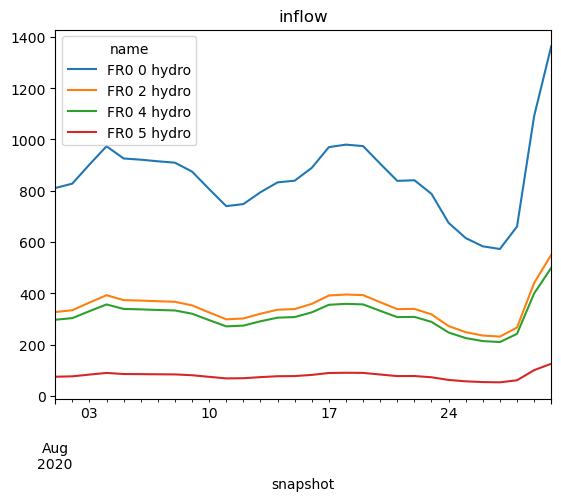


--- Time-Series for: p ---


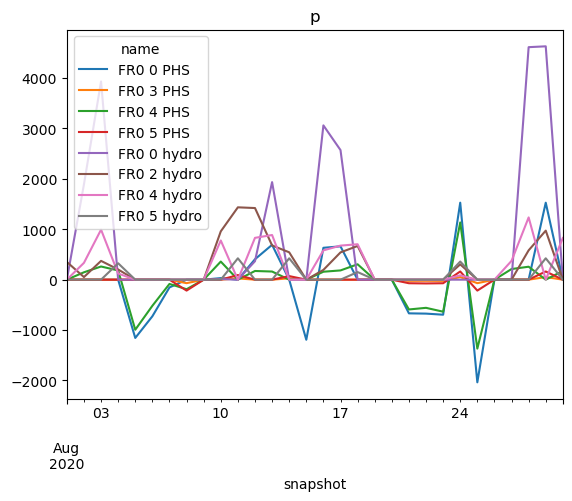


--- Time-Series for: p_dispatch ---


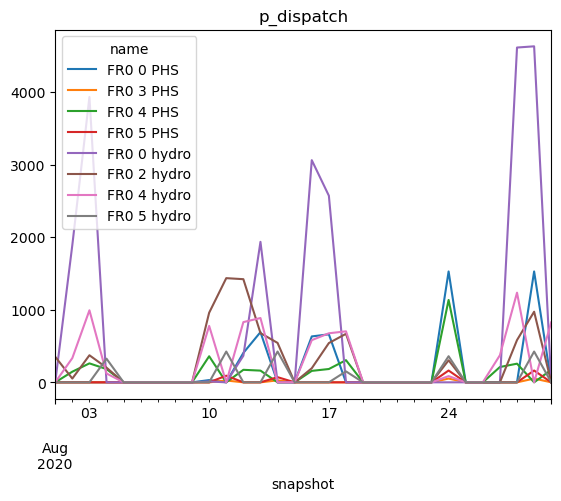


--- Time-Series for: p_store ---


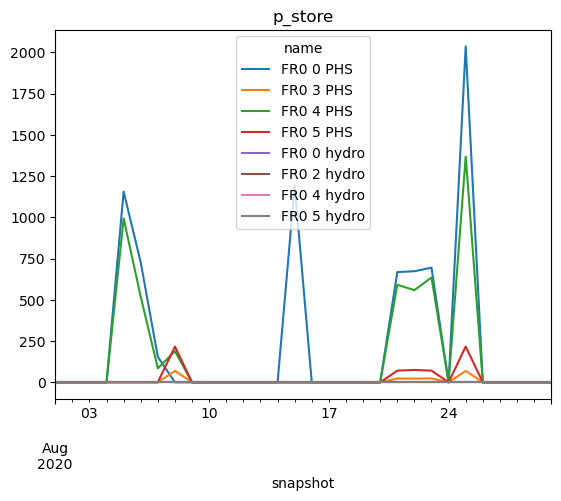

Time-Series for: q is empty or contains no data.

--- Time-Series for: state_of_charge ---


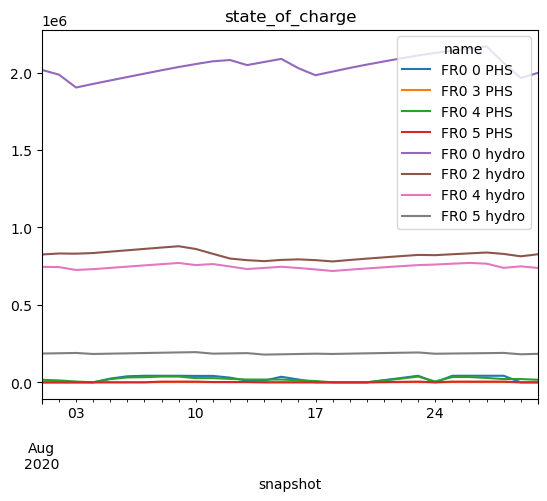


--- Time-Series for: spill ---


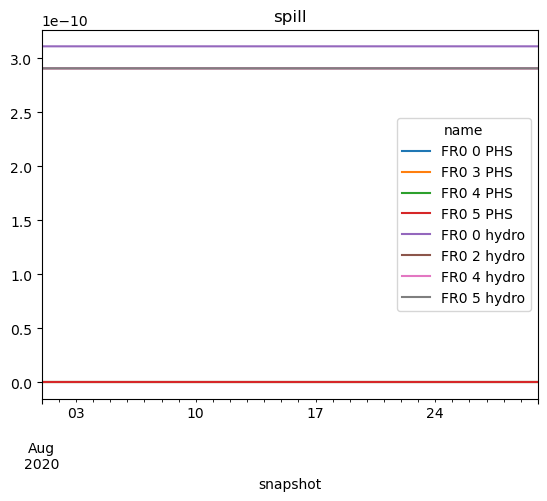

Time-Series for: mu_upper is empty or contains no data.
Time-Series for: mu_lower is empty or contains no data.
Time-Series for: mu_state_of_charge_set is empty or contains no data.
Time-Series for: mu_energy_balance is empty or contains no data.


In [75]:
# or as plots:
for key, df in n.storage_units_t.items():
    # Test if DataFrame is not empty and contains at least some non-null values
    if not df.empty and not df.isnull().all().all():
        print(f"\n--- Time-Series for: {key} ---")
        df.plot(title=key)
        plt.show()
    else:
        print(f"Time-Series for: {key} is empty or contains no data.")

Check for background of differences in dynamic data
- PHS has no inflow
- p can be negative for PHS
- p_store is 0 for hydro
- PHS has no Spill, but Spillage is ignorable tiny (Spill = Spillage, so no power Generation)

## Retrofitting "Hydro-2-PHS" Concept-1
Idea: take the static and dynamic dataframes for hydro (storage_units.carrier == "hydro" & storage_units_t.carrier == "hydro") and adjust the values to retrofitted-PHS-Configuration

**changes to static data (storage_units.carrier == "hydro")**
1. add charge capability by adjusting 
   1. **efficiency_store** from 0 to 0.866 (maybe also efficiency_dispatch from 0.9 to 0.866)
   2. **p_min_pu** from 0 to -1
2. change name
3. change carrier

**changes to the dynamic data (storage_units_t.carrier == "hydro")**  
1. keep inflow

=> no changes to dynamic data

**Try to re-optimize the system to account for changes**
=> does not account for investment costs

In [76]:
# copy hydro storage units and modify them to represent the retrofitted PHS units.
original_hydro = n.storage_units.index[n.storage_units.carrier == "hydro"].tolist()
original_su_p = n.storage_units_t.p[original_hydro].copy() if ("p" in n.storage_units_t and not n.storage_units_t.p.empty) else pd.DataFrame()
original_su_soc = n.storage_units_t.state_of_charge[original_hydro].copy() if ("state_of_charge" in n.storage_units_t and not n.storage_units_t.state_of_charge.empty) else pd.DataFrame()

retrofitted_hydro = n.storage_units[n.storage_units.carrier == "hydro"].copy()
# implement changes
retrofitted_hydro["efficiency_store"] = 0.8666
retrofitted_hydro["p_min_pu"] = -1.0
retrofitted_hydro["carrier"] = "PHS"
retrofitted_hydro.index = retrofitted_hydro.index + "_rf"
# check if changes are implemented correctly
retrofitted_hydro.head().T

name,FR0 0 hydro_rf,FR0 2 hydro_rf,FR0 4 hydro_rf,FR0 5 hydro_rf
bus,FR0 0,FR0 2,FR0 4,FR0 5
control,PQ,PQ,PQ,PQ
type,,,,
p_nom,4629.101911,1866.196178,1694.152866,424.0
p_nom_mod,0.0,0.0,0.0,0.0
p_nom_extendable,False,False,False,False
p_nom_min,0.0,0.0,0.0,0.0
p_nom_max,inf,inf,inf,inf
p_nom_set,NaN,NaN,NaN,NaN
p_min_pu,-1.0,-1.0,-1.0,-1.0


In [77]:
# copy hydro storage units and modify them to represent the retrofitted PHS units.
#retrofitted_hydro = n.storage_units[n.storage_units.carrier == "hydro"].copy()
# implement changes
n.storage_units.loc[n.storage_units.carrier == "hydro", "efficiency_store"] = 0.8666
n.storage_units.loc[n.storage_units.carrier == "hydro", "p_min_pu"] = -1.0
n.storage_units.rename(index=lambda x: f"{x}_rf" if x in n.storage_units[n.storage_units.carrier == "hydro"].index else x, inplace=True)
#n.storage_units.loc[n.storage_units.carrier == "hydro"].index = n.storage_units.loc[n.storage_units.carrier == "hydro"].index + "_rf"
n.storage_units.loc[n.storage_units.carrier == "hydro", "carrier"] = "PHS"
# check if changes are implemented correctly
n.storage_units.T

name,FR0 0 PHS,FR0 3 PHS,FR0 4 PHS,FR0 5 PHS,FR0 0 hydro_rf,FR0 2 hydro_rf,FR0 4 hydro_rf,FR0 5 hydro_rf
bus,FR0 0,FR0 3,FR0 4,FR0 5,FR0 0,FR0 2,FR0 4,FR0 5
control,PQ,PQ,PQ,PQ,PQ,PQ,PQ,PQ
type,,,,,,,,
p_nom,3660.0,240.0,1368.0,808.0,4629.101911,1866.196178,1694.152866,424.0
p_nom_mod,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
p_nom_extendable,False,False,False,False,False,False,False,False
p_nom_min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
p_nom_max,inf,inf,inf,inf,inf,inf,inf,inf
p_nom_set,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
p_min_pu,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0


renaming of retrofitted units time series needs to be fixed

In [78]:
# Fix: rename the time-series columns in storage_units_t to match the renamed storage unit indices
# The retrofitting step renamed hydro units in n.storage_units (adding '_rf' suffix),
# but the corresponding time-series DataFrames in n.storage_units_t still reference the old names.

# Build a mapping from old hydro names to new retrofitted names
hydro_rename_map = {}
for name in n.storage_units.index:
    if name.endswith('_rf'):
        old_name = name[:-3]  # Remove '_rf' suffix to get the original name
        hydro_rename_map[old_name] = name

print(f"Renaming mapping: {hydro_rename_map}")

# Apply the renaming to all time-series DataFrames in storage_units_t
for key in n.storage_units_t.keys():
    df = n.storage_units_t[key]
    if not df.empty:
        # Rename columns that match old hydro names
        cols_to_rename = {col: hydro_rename_map[col] for col in df.columns if col in hydro_rename_map}
        if cols_to_rename:
            n.storage_units_t[key] = df.rename(columns=cols_to_rename)
            print(f"  Renamed columns in '{key}': {cols_to_rename}")

print("\nTime-series renaming complete.")
print(f"Storage unit names: {list(n.storage_units.index)}")
print(f"Inflow columns: {list(n.storage_units_t['inflow'].columns)}")


Renaming mapping: {'FR0 0 hydro': 'FR0 0 hydro_rf', 'FR0 2 hydro': 'FR0 2 hydro_rf', 'FR0 4 hydro': 'FR0 4 hydro_rf', 'FR0 5 hydro': 'FR0 5 hydro_rf'}
  Renamed columns in 'inflow': {'FR0 0 hydro': 'FR0 0 hydro_rf', 'FR0 2 hydro': 'FR0 2 hydro_rf', 'FR0 4 hydro': 'FR0 4 hydro_rf', 'FR0 5 hydro': 'FR0 5 hydro_rf'}
  Renamed columns in 'p': {'FR0 0 hydro': 'FR0 0 hydro_rf', 'FR0 2 hydro': 'FR0 2 hydro_rf', 'FR0 4 hydro': 'FR0 4 hydro_rf', 'FR0 5 hydro': 'FR0 5 hydro_rf'}
  Renamed columns in 'p_dispatch': {'FR0 0 hydro': 'FR0 0 hydro_rf', 'FR0 2 hydro': 'FR0 2 hydro_rf', 'FR0 4 hydro': 'FR0 4 hydro_rf', 'FR0 5 hydro': 'FR0 5 hydro_rf'}
  Renamed columns in 'p_store': {'FR0 0 hydro': 'FR0 0 hydro_rf', 'FR0 2 hydro': 'FR0 2 hydro_rf', 'FR0 4 hydro': 'FR0 4 hydro_rf', 'FR0 5 hydro': 'FR0 5 hydro_rf'}
  Renamed columns in 'state_of_charge': {'FR0 0 hydro': 'FR0 0 hydro_rf', 'FR0 2 hydro': 'FR0 2 hydro_rf', 'FR0 4 hydro': 'FR0 4 hydro_rf', 'FR0 5 hydro': 'FR0 5 hydro_rf'}
  Renamed columns in

In [79]:
n.optimize()

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.53s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 4461 primals, 9178 duals
Objective: 4.54e+08
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-ext-s-lower, Line-ext-s-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-fix-p_dispatch-lower, StorageUnit-fix-p_dispatch-upper, StorageUnit-fix-p_store-lower, StorageUnit-fix-p_store-upper, StorageUnit-fix-state_of_charge-lower, StorageUnit-fix-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


('ok', 'optimal')

## Post-Optimization Analysis
After running the optimization with the retrofitted hydro-to-PHS storage units, we can analyze the results
to understand how the network dispatch changed.

In [80]:
# Display the objective value (total system cost)
print(f"Objective value (total system cost): {n.objective:.2f} €")
#print(f"Optimization status: {n.optimization_status}")
print()

# Summary of storage units after optimization
print("=== Storage Units Summary ===")
su = n.storage_units[["bus", "carrier", "p_nom", "p_nom_opt", "max_hours", "efficiency_store", "efficiency_dispatch"]]
print(su.to_string())


Objective value (total system cost): 453629607.26 €

=== Storage Units Summary ===
                  bus carrier        p_nom    p_nom_opt   max_hours  efficiency_store  efficiency_dispatch
name                                                                                                      
FR0 0 PHS       FR0 0     PHS  3660.000000  3660.000000   11.564449          0.866025             0.866025
FR0 3 PHS       FR0 3     PHS   240.000000   240.000000    6.000000          0.866025             0.866025
FR0 4 PHS       FR0 4     PHS  1368.000000  1368.000000   27.122183          0.866025             0.866025
FR0 5 PHS       FR0 5     PHS   808.000000   808.000000    5.573020          0.866025             0.866025
FR0 0 hydro_rf  FR0 0     PHS  4629.101911  4629.101911  881.198638          0.866600             0.900000
FR0 2 hydro_rf  FR0 2     PHS  1866.196178  1866.196178  881.198638          0.866600             0.900000
FR0 4 hydro_rf  FR0 4     PHS  1694.152866  1694.152866  881.

### Generator Dispatch
Visualize the power output of all generators over the optimization horizon.

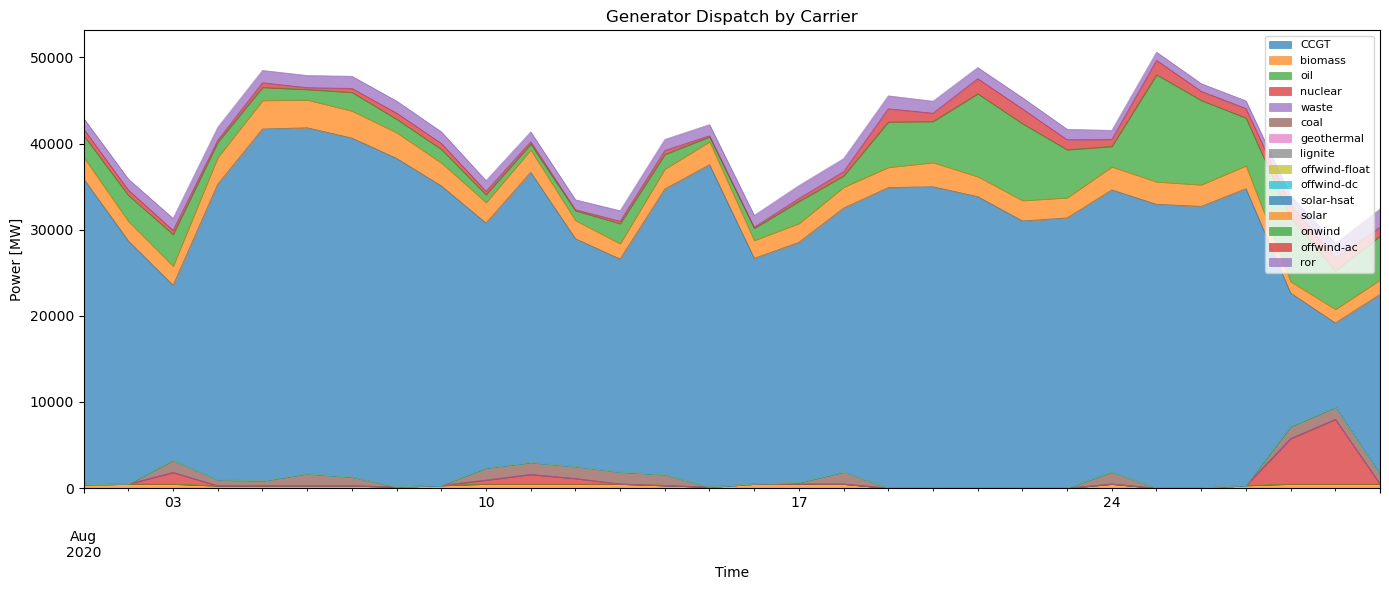

In [81]:
# Plot generator dispatch (power output over time)
fig, ax = plt.subplots(figsize=(14, 6))

# Group generators by carrier for stacked area plot
gen_p = n.generators_t.p
if not gen_p.empty:
    # Aggregate by carrier
    carrier_dispatch = pd.DataFrame(index=gen_p.index)
    for carrier in n.generators.carrier.unique():
        gen_names = n.generators[n.generators.carrier == carrier].index
        matching_cols = [c for c in gen_p.columns if c in gen_names]
        if matching_cols:
            carrier_dispatch[carrier] = gen_p[matching_cols].sum(axis=1)
    
    carrier_dispatch.plot.area(ax=ax, alpha=0.7, linewidth=0.5)
    ax.set_xlabel("Time")
    ax.set_ylabel("Power [MW]")
    ax.set_title("Generator Dispatch by Carrier")
    ax.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("No generator dispatch data available.")


### Storage Unit Dispatch (PHS)
Visualize the charging/discharging behavior of all PHS storage units (including retrofitted ones).

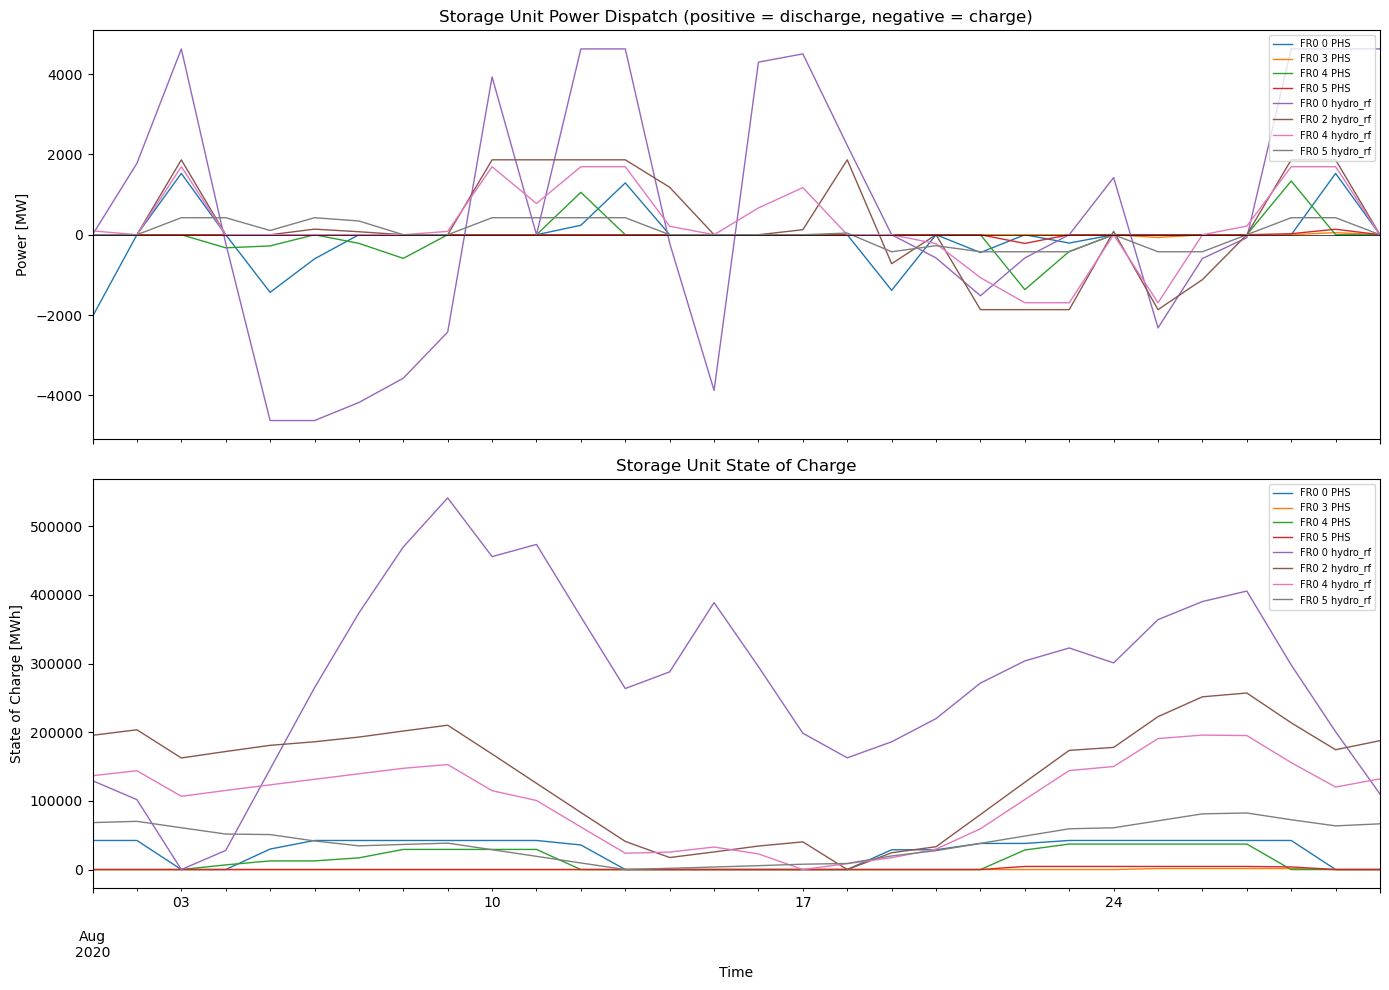

In [82]:
# Plot storage unit dispatch (p = dispatch - store)
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Power dispatch/store
su_p = n.storage_units_t.p
if not su_p.empty:
    su_p.plot(ax=axes[0], linewidth=1)
    axes[0].set_ylabel("Power [MW]")
    axes[0].set_title("Storage Unit Power Dispatch (positive = discharge, negative = charge)")
    axes[0].legend(loc="upper right", fontsize=7)
    axes[0].axhline(y=0, color='k', linestyle='-', linewidth=0.5)

# State of charge
su_soc = n.storage_units_t.state_of_charge
if not su_soc.empty:
    su_soc.plot(ax=axes[1], linewidth=1)
    axes[1].set_xlabel("Time")
    axes[1].set_ylabel("State of Charge [MWh]")
    axes[1].set_title("Storage Unit State of Charge")
    axes[1].legend(loc="upper right", fontsize=7)

plt.tight_layout()
plt.show()


### Retrofitted Units vs Original PHS
Compare the dispatch behavior of the original PHS units and the retrofitted hydro-to-PHS units.

Original PHS units: ['FR0 0 PHS', 'FR0 3 PHS', 'FR0 4 PHS', 'FR0 5 PHS']
Retrofitted PHS units: ['FR0 0 hydro_rf', 'FR0 2 hydro_rf', 'FR0 4 hydro_rf', 'FR0 5 hydro_rf']


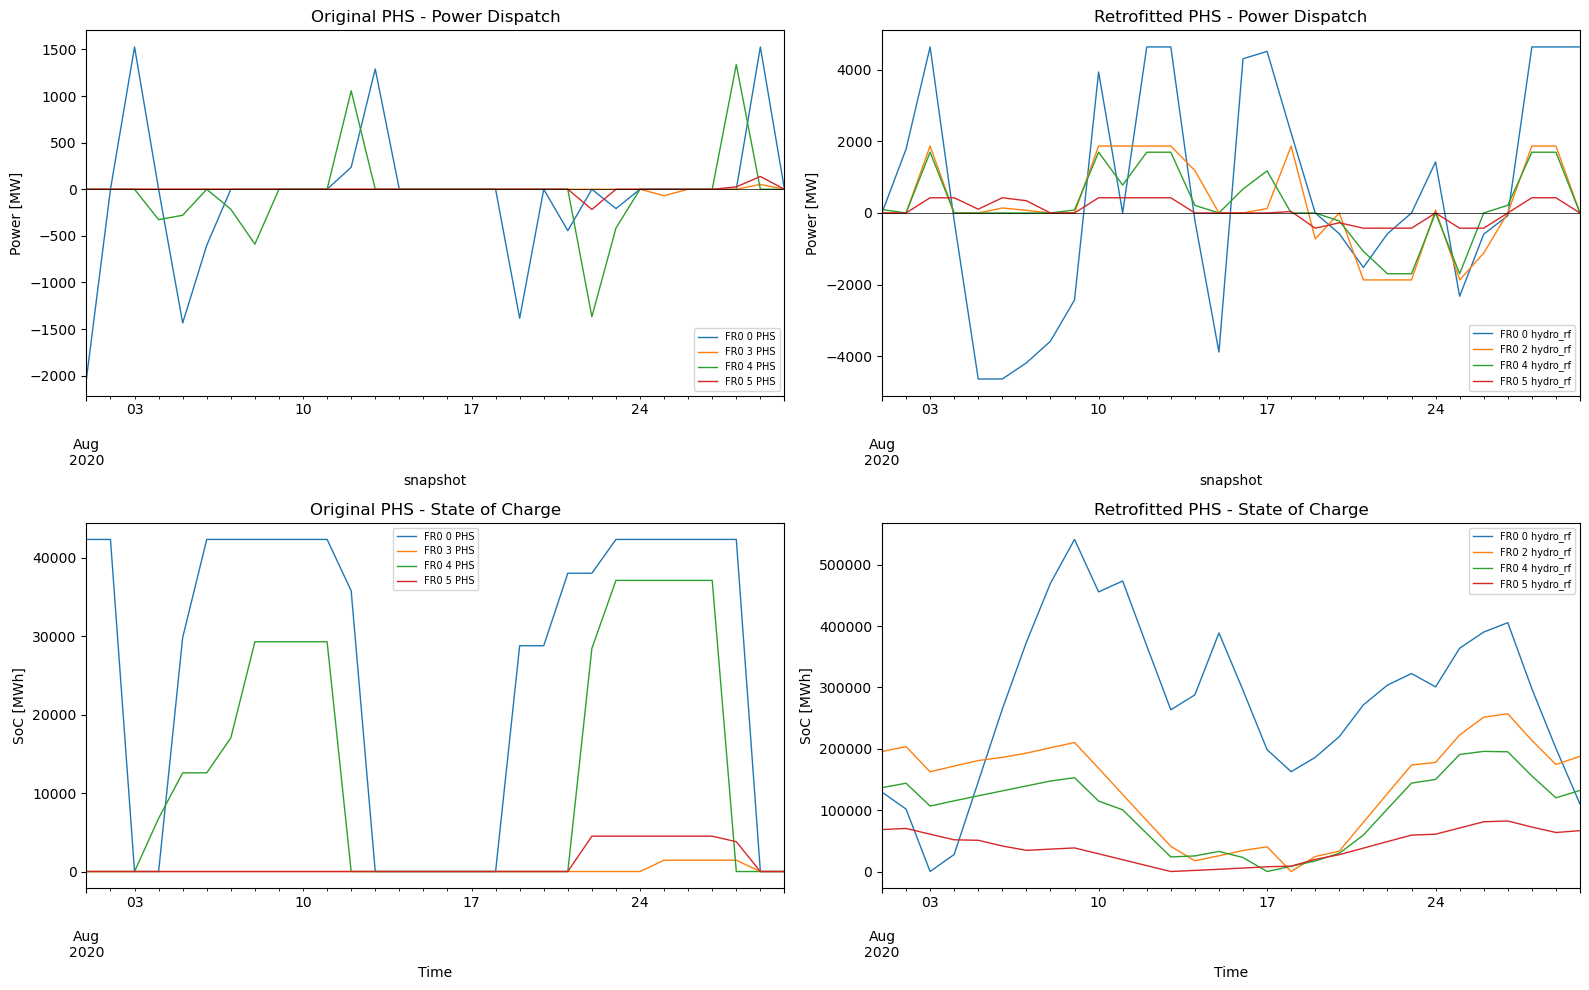

In [83]:
### OLD
# Separate original PHS and retrofitted PHS units
original_phs = [name for name in n.storage_units.index if 'PHS' in name and '_rf' not in name]
retrofitted_phs = [name for name in n.storage_units.index if '_rf' in name]

print(f"Original PHS units: {original_phs}")
print(f"Retrofitted PHS units: {retrofitted_phs}")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Original PHS dispatch
su_p = n.storage_units_t.p
if not su_p.empty:
    orig_cols = [c for c in su_p.columns if c in original_phs]
    retro_cols = [c for c in su_p.columns if c in retrofitted_phs]
    
    if orig_cols:
        su_p[orig_cols].plot(ax=axes[0, 0], linewidth=1)
        axes[0, 0].set_title("Original PHS - Power Dispatch")
        axes[0, 0].set_ylabel("Power [MW]")
        axes[0, 0].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
        axes[0, 0].legend(fontsize=7)
    
    if retro_cols:
        su_p[retro_cols].plot(ax=axes[0, 1], linewidth=1)
        axes[0, 1].set_title("Retrofitted PHS - Power Dispatch")
        axes[0, 1].set_ylabel("Power [MW]")
        axes[0, 1].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
        axes[0, 1].legend(fontsize=7)

# State of charge comparison
su_soc = n.storage_units_t.state_of_charge
if not su_soc.empty:
    orig_soc_cols = [c for c in su_soc.columns if c in original_phs]
    retro_soc_cols = [c for c in su_soc.columns if c in retrofitted_phs]
    
    if orig_soc_cols:
        su_soc[orig_soc_cols].plot(ax=axes[1, 0], linewidth=1)
        axes[1, 0].set_title("Original PHS - State of Charge")
        axes[1, 0].set_ylabel("SoC [MWh]")
        axes[1, 0].set_xlabel("Time")
        axes[1, 0].legend(fontsize=7)
    
    if retro_soc_cols:
        su_soc[retro_soc_cols].plot(ax=axes[1, 1], linewidth=1)
        axes[1, 1].set_title("Retrofitted PHS - State of Charge")
        axes[1, 1].set_ylabel("SoC [MWh]")
        axes[1, 1].set_xlabel("Time")
        axes[1, 1].legend(fontsize=7)

plt.tight_layout()
plt.show()


Original hydro units: ['FR0 0 hydro', 'FR0 2 hydro', 'FR0 4 hydro', 'FR0 5 hydro']
Retrofitted PHS units: ['FR0 0 hydro_rf', 'FR0 2 hydro_rf', 'FR0 4 hydro_rf', 'FR0 5 hydro_rf']


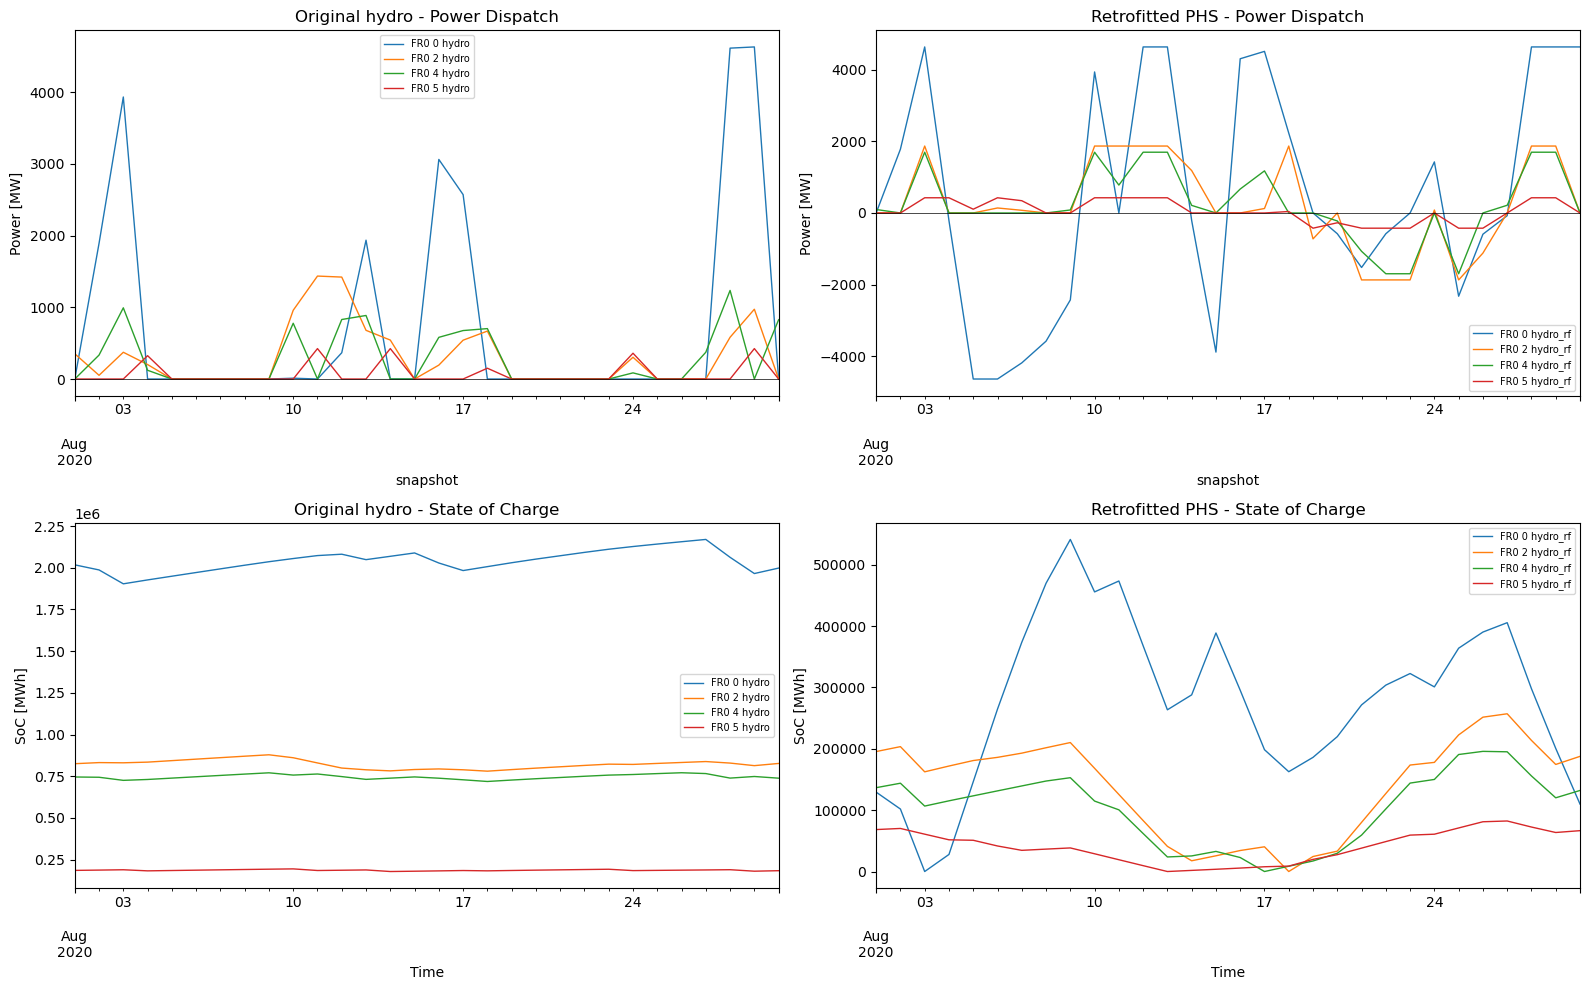

In [89]:
### NEW: Comparison of original hydro vs retrofitted PHS units
# Verwende die gespeicherten original hydro Daten vor dem Retrofit
original_hydro = original_hydro if 'original_hydro' in globals() else []
retrofitted_phs = [name for name in n.storage_units.index if name.endswith('_rf')]

print(f"Original hydro units: {original_hydro}")
print(f"Retrofitted PHS units: {retrofitted_phs}")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Original hydro dispatch (aus gespeicherten Zeitreihen vor Retrofit)
orig_plot_p = original_su_p if 'original_su_p' in globals() and not original_su_p.empty else pd.DataFrame()
if not orig_plot_p.empty:
    orig_plot_p.plot(ax=axes[0, 0], linewidth=1)
    axes[0, 0].set_title("Original hydro - Power Dispatch")
    axes[0, 0].set_ylabel("Power [MW]")
    axes[0, 0].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    axes[0, 0].legend(fontsize=7)

# Retrofitted PHS dispatch (aus aktuellen Zeitreihen nach Optimierung)
su_p = n.storage_units_t.p
if not su_p.empty:
    retro_cols = [c for c in su_p.columns if c in retrofitted_phs]
    if retro_cols:
        su_p[retro_cols].plot(ax=axes[0, 1], linewidth=1)
        axes[0, 1].set_title("Retrofitted PHS - Power Dispatch")
        axes[0, 1].set_ylabel("Power [MW]")
        axes[0, 1].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
        axes[0, 1].legend(fontsize=7)

# State of charge comparison - Original hydro
orig_plot_soc = original_su_soc if 'original_su_soc' in globals() and not original_su_soc.empty else pd.DataFrame()
if not orig_plot_soc.empty:
    orig_plot_soc.plot(ax=axes[1, 0], linewidth=1)
    axes[1, 0].set_title("Original hydro - State of Charge")
    axes[1, 0].set_ylabel("SoC [MWh]")
    axes[1, 0].set_xlabel("Time")
    axes[1, 0].legend(fontsize=7)

# State of charge comparison - Retrofitted PHS
su_soc = n.storage_units_t.state_of_charge
if not su_soc.empty:
    retro_soc_cols = [c for c in su_soc.columns if c in retrofitted_phs]
    if retro_soc_cols:
        su_soc[retro_soc_cols].plot(ax=axes[1, 1], linewidth=1)
        axes[1, 1].set_title("Retrofitted PHS - State of Charge")
        axes[1, 1].set_ylabel("SoC [MWh]")
        axes[1, 1].set_xlabel("Time")
        axes[1, 1].legend(fontsize=7)

plt.tight_layout()
plt.show()


### Energy Summary
Total energy dispatched and stored by each storage unit type.

In [85]:
# Compute total energy dispatched and stored for each storage unit
su_p_dispatch = n.storage_units_t.p_dispatch
su_p_store = n.storage_units_t.p_store

if not su_p_dispatch.empty and not su_p_store.empty:
    # Total energy dispatched (positive) and stored (positive = energy going in)
    energy_dispatched = su_p_dispatch.sum()  # MWh (since snapshots are daily in this case)
    energy_stored = su_p_store.sum()
    
    summary = pd.DataFrame({
        'Carrier': [n.storage_units.loc[name, 'carrier'] if name in n.storage_units.index else 'Unknown' for name in energy_dispatched.index],
        'Retrofitted': ['Yes' if '_rf' in name else 'No' for name in energy_dispatched.index],
        'Energy Dispatched [MWh]': energy_dispatched.values,
        'Energy Stored [MWh]': energy_stored.values,
        'p_nom [MW]': [n.storage_units.loc[name, 'p_nom'] if name in n.storage_units.index else 0 for name in energy_dispatched.index],
    }, index=energy_dispatched.index)
    
    print(summary.to_string())
else:
    print("No dispatch/store data available.")


               Carrier Retrofitted  Energy Dispatched [MWh]  Energy Stored [MWh]   p_nom [MW]
name                                                                                         
FR0 0 PHS          PHS          No              4581.911152          6109.214870  3660.000000
FR0 3 PHS          PHS          No                51.961524            69.282032   240.000000
FR0 4 PHS          PHS          No              2395.510451          3194.013934  1368.000000
FR0 5 PHS          PHS          No               162.488016           216.650689   808.000000
FR0 0 hydro_rf     PHS         Yes             45940.839529         29402.411729  4629.101911
FR0 2 hydro_rf     PHS         Yes             16533.364346          9305.239338  1866.196178
FR0 4 hydro_rf     PHS         Yes             13391.765647          6373.647281  1694.152866
FR0 5 hydro_rf     PHS         Yes              4304.719822          2817.202289   424.000000


### Spill Analysis
Examine if there is any energy spillage in the storage units.

In [86]:
# Check for spillage
su_spill = n.storage_units_t.spill
if not su_spill.empty:
    total_spill = su_spill.sum()
    if total_spill.sum() > 1e-6:
        print("Total spillage by storage unit:")
        print(total_spill[total_spill > 1e-6].to_string())
        
        fig, ax = plt.subplots(figsize=(14, 4))
        spill_cols = total_spill[total_spill > 1e-6].index
        su_spill[spill_cols].plot(ax=ax, linewidth=1)
        ax.set_xlabel("Time")
        ax.set_ylabel("Spill [MWh]")
        ax.set_title("Storage Unit Spillage")
        ax.legend(fontsize=7)
        plt.tight_layout()
        plt.show()
    else:
        print("No significant spillage detected.")
else:
    print("No spill data available.")


No significant spillage detected.


### Network Visualization
Plot the network with optimized capacities.

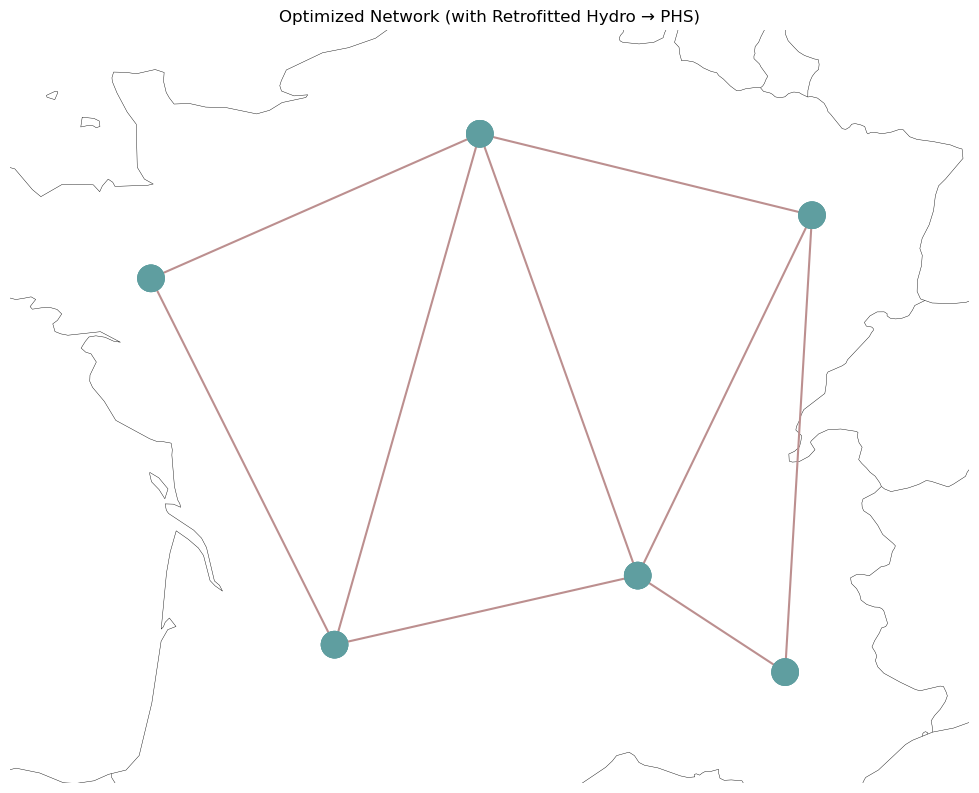

In [87]:
# Plot the network
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": ccrs.EqualEarth()})
n.plot(ax=ax, margin=0.2)
ax.set_title("Optimized Network (with Retrofitted Hydro → PHS)")
plt.tight_layout()
plt.show()


### Save Retrofitted Network
Save the optimized network to a new .nc file for further analysis.

In [88]:
# Save the retrofitted and optimized network
output_path = "../results/FR_2020-08_6_clusters_2030/networks/retrofitted_s_6_elec_.nc"
n.export_to_netcdf(output_path)
print(f"Retrofitted network saved to: {output_path}")


INFO:pypsa.network.io:Exported network 'Unnamed Network' saved to '../results/FR_2020-08_6_clusters_2030/networks/retrofitted_s_6_elec_.nc contains: links, carriers, generators, lines, storage_units, buses, loads, stores, sub_networks


Retrofitted network saved to: ../results/FR_2020-08_6_clusters_2030/networks/retrofitted_s_6_elec_.nc


## Summary & Next Steps

This notebook demonstrated a basic retrofitting approach for converting conventional **hydro** storage units
 into **pumped hydro storage (PHS)** units in a pre-built pypsa-eur network.

**Key modifications applied to hydro units:**
- Set `efficiency_store` to 0.8666 (enabling pumping capability)
- Set `p_min_pu` to -1.0 (allowing full bi-directional power flow)
- Changed `carrier` to "PHS"
- Renamed indices with `_rf` suffix and updated time-series references

**Next steps / improvements:**
- Add realistic retrofitting costs (capital_cost) — approximately ~2000 €/kW
- Use per-plant data instead of country aggregates where available
- Make retrofitting a decision variable in the optimization (optional retrofit)
- Validate results against real-world PHS operation data
- Compare total system costs before and after retrofitting
